## EDA and Feature engineering on Uber dataset

Dataset link: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard?select=ncr_ride_bookings.csv

### Objective
+ To understand the customer behaviour 
+ Driver and customer relation
+ Driver behaviour 
+ Reasons for incomplete ride

#### Importing require packages

In [71]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')


from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Dataset loading and basic overview

In [72]:
df = pd.read_csv("./data/ncr_ride_bookings.csv")

In [4]:
df.shape 

(150000, 21)

In [21]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
df.tail()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [7]:
df.columns


Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')

In [8]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [9]:
df.duplicated().sum()
# no duplicates

np.int64(0)

### Univariant Analysis 

### Date 

In [28]:
df["Date"].isnull().sum()

np.int64(0)

In [31]:
x = pd.to_datetime(df["Date"])
x 

0        2024-03-23
1        2024-11-29
2        2024-08-23
3        2024-10-21
4        2024-09-16
            ...    
149995   2024-11-11
149996   2024-11-24
149997   2024-09-18
149998   2024-10-05
149999   2024-03-10
Name: Date, Length: 150000, dtype: datetime64[us]

### Years 
+ All the data set are from 2024 

In [36]:
years = x.dt.year
print(years.value_counts())

Date
2024    150000
Name: count, dtype: int64


### Months 
+ Traffic in each month is almost equal

In [38]:
months = x.dt.month
print(months.value_counts())


Date
7     12897
1     12861
5     12778
3     12719
10    12651
8     12636
6     12440
11    12394
12    12250
9     12248
4     12199
2     11927
Name: count, dtype: int64


### Days 

In [44]:
days = x.dt.day 
print(days.value_counts())

Date
16    5106
9     5039
4     5038
1     5036
6     5019
5     5017
14    5006
26    4989
17    4982
3     4979
22    4974
24    4937
15    4922
8     4920
12    4919
18    4914
7     4914
25    4905
21    4896
10    4895
2     4894
13    4883
20    4878
27    4875
11    4872
29    4858
28    4836
19    4832
23    4830
30    4442
31    2393
Name: count, dtype: int64


### Booking Status

+ 62% booking is completed 
+ More then half of incomplete booking is cancled by driver so we need to find the reason why it is cancled by driver

In [26]:
df["Booking Status"].value_counts()


Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [4]:
df["Booking Status"].value_counts(normalize=True) * 100 

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

<Axes: xlabel='Booking Status', ylabel='count'>

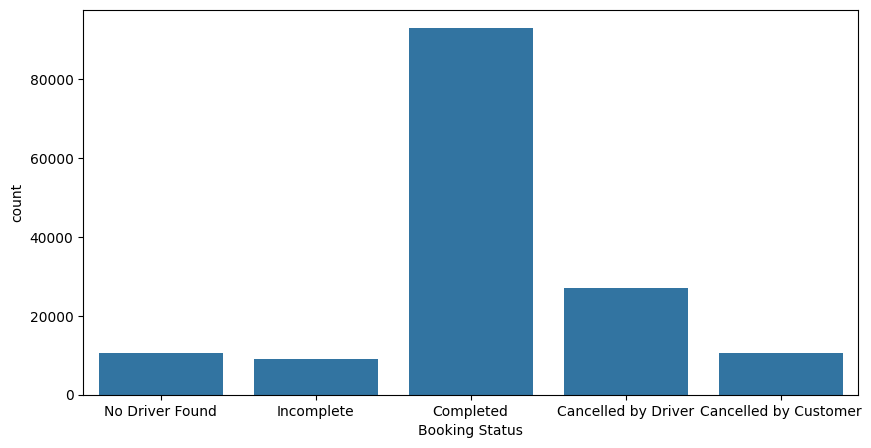

In [3]:
plt.figure(figsize=(10,5))
sns.countplot(x="Booking Status",data=df)

### Vehicle Type

+ Maximum number of vehicle use is Auto and Uber is minimum
+ We can find the relation between incomplete ride and vechile types

In [6]:
df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

<Axes: xlabel='Vehicle Type', ylabel='count'>

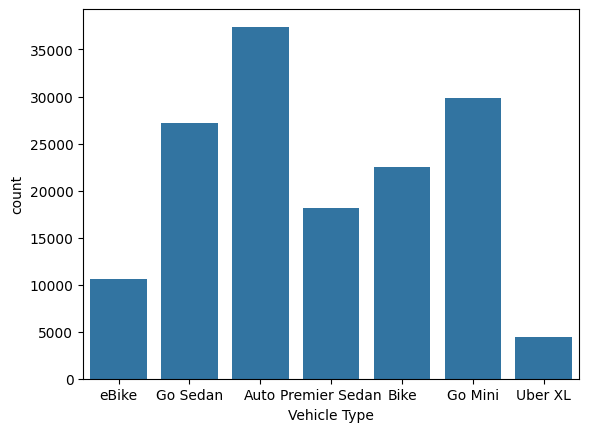

In [7]:
sns.countplot(x="Vehicle Type",data=df)

([<matplotlib.patches.Wedge at 0x1145c0950>,
 [Text(0.7791358643842407, 0.7764968157244576, 'eBike'),
  Text(-0.6399105240674839, 0.8947147708558736, 'Go Sedan'),
  Text(-1.067745652182047, -0.26442243143563904, 'Auto'),
  Text(-0.3124387834764199, -1.054695219757715, 'Premier Sedan'),
  Text(0.5870149325864867, -0.9302760175993374, 'Bike'),
  Text(1.0099414768505635, -0.435910785983672, 'Go Mini'),
  Text(1.0952281206906556, -0.10234922397563588, 'Uber XL')],
 [Text(0.4249831987550403, 0.4235437176678859, '24.9%'),
  Text(-0.34904210403680935, 0.48802623864865824, '19.9%'),
  Text(-0.5824067193720256, -0.1442304171467122, '18.1%'),
  Text(-0.17042115462350174, -0.5752883016860264, '15.0%'),
  Text(0.32018996322899274, -0.5074232823269113, '12.1%'),
  Text(0.5508771691912164, -0.23776951962745743, '7.0%'),
  Text(0.5973971567403575, -0.055826849441255925, '3.0%')])

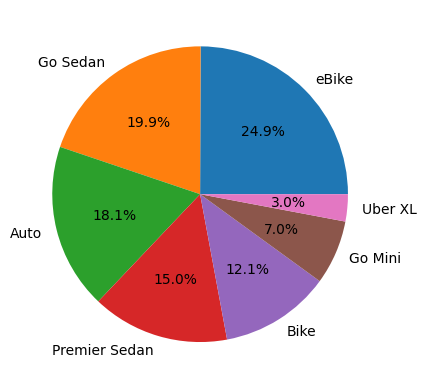

In [9]:
plt.pie(x=df["Vehicle Type"].value_counts(),autopct="%1.1f%%",labels=df["Vehicle Type"].unique())

### Pickup Location

In [15]:
df["Pickup Location"].nunique()

176

In [16]:
df["Pickup Location"].value_counts().head(10)

Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64

In [17]:
df["Pickup Location"].value_counts().tail(10)

Pickup Location
Old Gurgaon         807
Dilshad Garden      804
Kalkaji             803
Bahadurgarh         802
Mandi House         800
Chirag Delhi        800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, dtype: int64

### Drop Location

In [20]:
df["Drop Location"].nunique()

176

In [19]:
df["Drop Location"].value_counts().head(10)

Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Madipur               902
Name: count, dtype: int64

In [21]:
df["Drop Location"].value_counts().tail(10)


Drop Location
Pragati Maidan      803
Okhla               802
Vasant Kunj         802
IFFCO Chowk         801
Seelampur           800
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, dtype: int64

### Avg VTAT: Average time for driver to reach pickup location (in minutes)

In [25]:
df["Avg VTAT"].isnull().sum()

np.int64(10500)

In [22]:
df["Avg VTAT"].describe()

count    139500.000000
mean          8.456352
std           3.773564
min           2.000000
25%           5.300000
50%           8.300000
75%          11.300000
max          20.000000
Name: Avg VTAT, dtype: float64

<Axes: xlabel='Avg VTAT', ylabel='Count'>

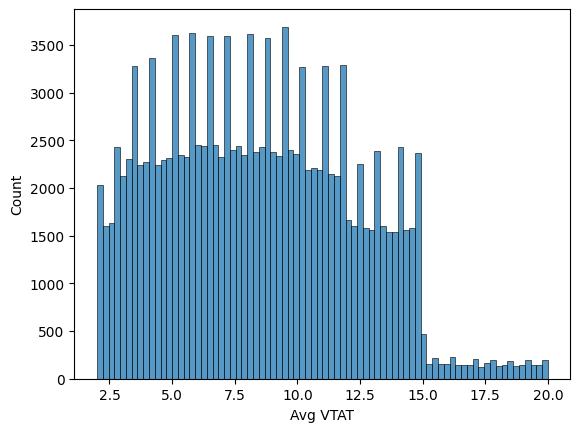

In [23]:
sns.histplot(x="Avg VTAT",data=df)

### Avg CTAT: Average trip duration from pickup to destination (in minutes)

+ There is the issue we can complete booking status is 93000 and here we can len of avg duration take to reach destination is 102000 so extra 9000 booking is extra.
+ So the issue the extra 9000 data is find even though those ride aren't completed but they trave for some distance so it show in CTAT 

In [41]:
df["Avg CTAT"].describe()

count    102000.000000
mean         29.149636
std           8.902577
min          10.000000
25%          21.600000
50%          28.800000
75%          36.800000
max          45.000000
Name: Avg CTAT, dtype: float64

In [28]:
df["Avg CTAT"].isnull().sum()

np.int64(48000)

In [40]:
x = df.loc[df["Booking Status"] == "Incomplete", ["Incomplete Rides"]]
x.value_counts()

Incomplete Rides
1.0                 9000
Name: count, dtype: int64

In [36]:
len(df[df["Booking Status"]=="Incomplete"])

9000

### Incomplete Rides 

In [43]:
df["Incomplete Rides"].isnull().sum()

np.int64(141000)

In [42]:
df["Incomplete Rides"].value_counts()

Incomplete Rides
1.0    9000
Name: count, dtype: int64

### Booking Value : Total fare amount for the ride 

In [44]:
df["Booking Value"].describe()

count    102000.000000
mean        508.295912
std         395.805774
min          50.000000
25%         234.000000
50%         414.000000
75%         689.000000
max        4277.000000
Name: Booking Value, dtype: float64

<Axes: xlabel='Booking Value', ylabel='Count'>

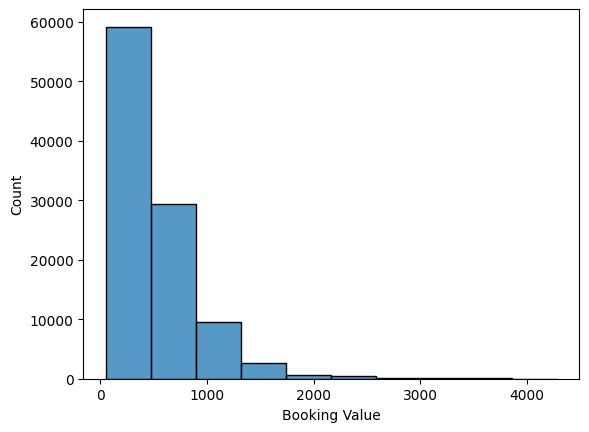

In [49]:
sns.histplot(x="Booking Value",data=df,bins=10)

<Axes: xlabel='Booking Value', ylabel='Density'>

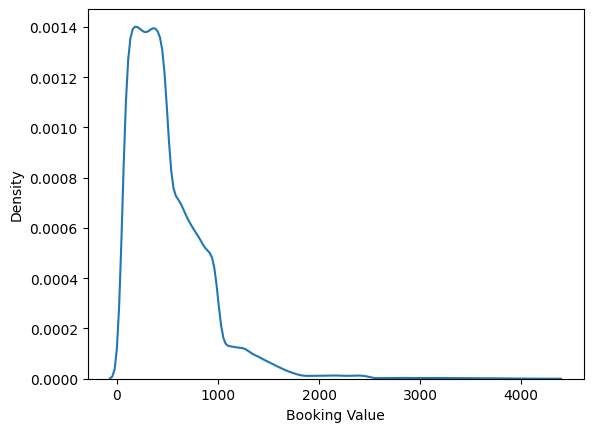

In [51]:
sns.kdeplot(x="Booking Value",data=df)


### Ride Distance 

In [3]:
df["Ride Distance"].describe()

count    102000.000000
mean         24.637012
std          14.002138
min           1.000000
25%          12.460000
50%          23.720000
75%          36.820000
max          50.000000
Name: Ride Distance, dtype: float64

Text(0.5, 0, 'Ride distance(in KM)')

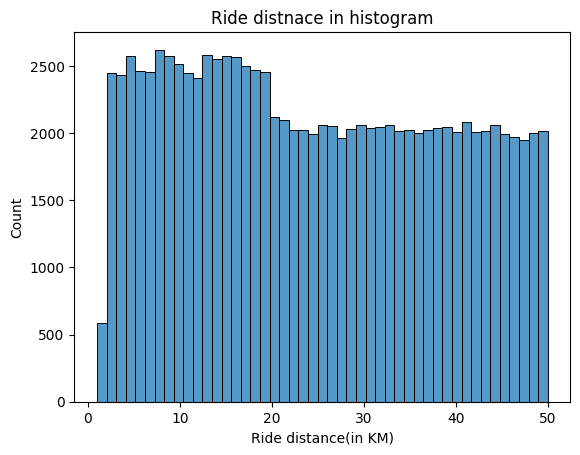

In [5]:
plt.title("Ride distnace in histogram")
sns.histplot(x="Ride Distance",data=df)
plt.xlabel("Ride distance(in KM)")

### Driver Ratings 
+ Average rating of ride by drive is above 4

In [19]:
df["Driver Ratings"].isnull().sum()

np.int64(57000)

In [6]:
df["Driver Ratings"].describe()

count    93000.000000
mean         4.230992
std          0.436871
min          3.000000
25%          4.100000
50%          4.300000
75%          4.600000
max          5.000000
Name: Driver Ratings, dtype: float64

Text(0, 0.5, 'Counts')

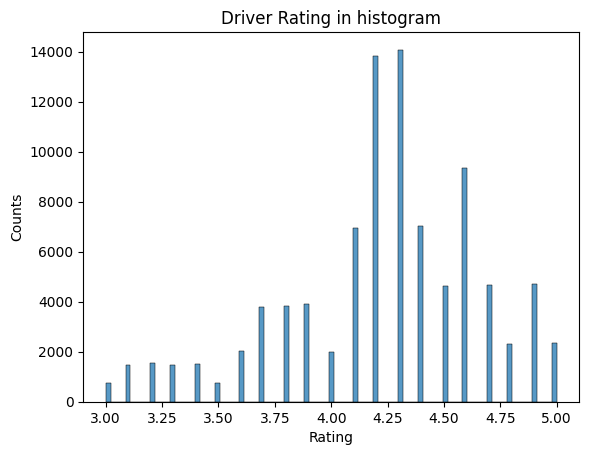

In [14]:
plt.title("Driver Rating in histogram")
sns.histplot(x="Driver Ratings",data=df)
plt.xlabel("Rating")
plt.ylabel("Counts")

<Axes: title={'center': 'KDEplot of Driver Rating'}, xlabel='Driver Ratings', ylabel='Density'>

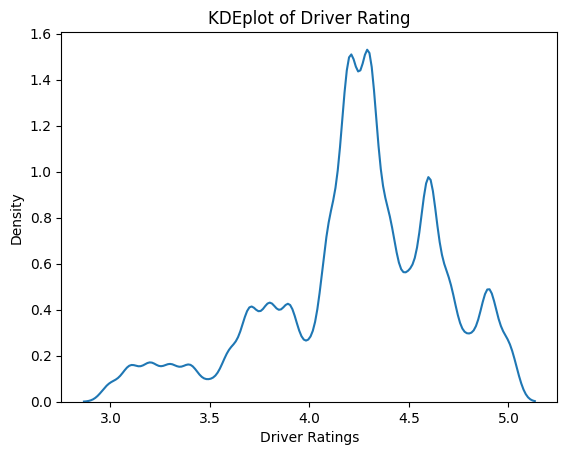

In [16]:
plt.title("KDEplot of Driver Rating")
sns.kdeplot(x="Driver Ratings",data=df)

### Customer Rating 

In [20]:
df["Driver Ratings"].isnull().sum()


np.int64(57000)

In [17]:
df["Customer Rating"].describe()

count    93000.000000
mean         4.404584
std          0.437819
min          3.000000
25%          4.200000
50%          4.500000
75%          4.800000
max          5.000000
Name: Customer Rating, dtype: float64

Text(0, 0.5, 'Counts')

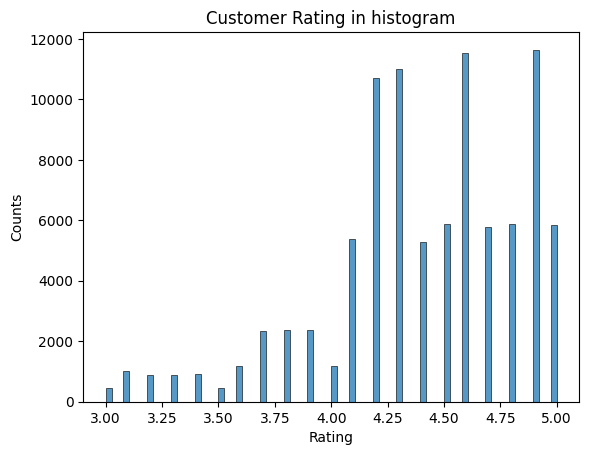

In [21]:
plt.title("Customer Rating in histogram")
sns.histplot(x="Customer Rating",data=df)
plt.xlabel("Rating")
plt.ylabel("Counts")

<Axes: title={'center': 'KDEplot of Customer Rating'}, xlabel='Customer Rating', ylabel='Density'>

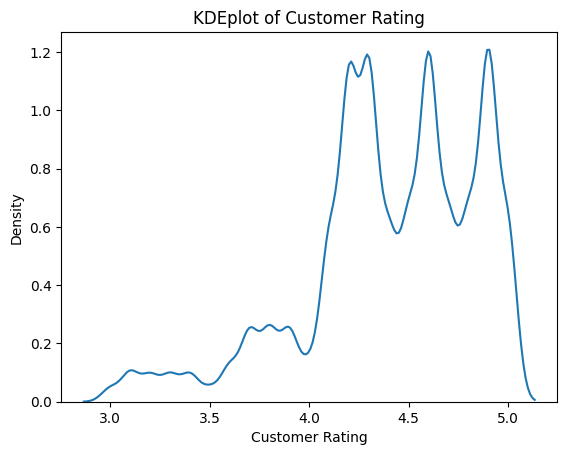

In [23]:
plt.title("KDEplot of Customer Rating")
sns.kdeplot(x="Customer Rating",data=df)

### Payment Method 

In [26]:
df["Payment Method"].isnull().sum()

np.int64(48000)

In [24]:
df["Payment Method"].describe()

count     102000
unique         5
top          UPI
freq       45909
Name: Payment Method, dtype: object

<Axes: xlabel='Payment Method', ylabel='count'>

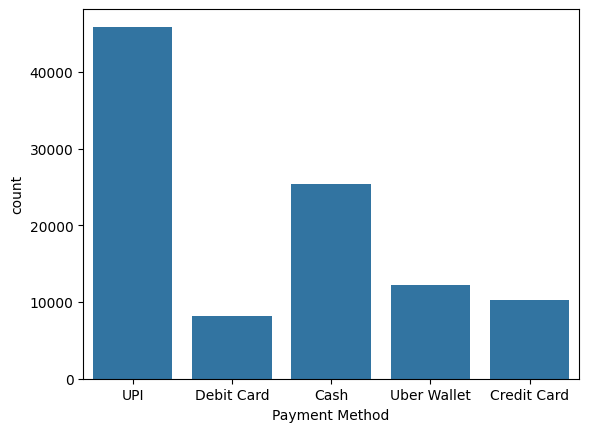

In [25]:
sns.countplot(x="Payment Method",data=df)

### Univariant analysis on Paragraph column
#### Cancelled Rides by Customer
+ On average each cancelation message contain 22 words 
+ Maximum ride cancle is due to the driver not moving towards the pickup location
+ Another reasons is also ac not working in rider vechiles
+ Some ride is cancel due to the driver ask for cancelation 

In [85]:
total_null_value = df["Cancelled Rides by Customer"].isnull().sum()
dataset_len = df.shape[0] 

total_number_of_cancelation = dataset_len - total_null_value
print("Total cancelation:",total_number_of_cancelation)

Total cancelation: 10500


In [86]:
# only dataset cancle by customer
customer_cancle_df = df.loc[df["Cancelled Rides by Customer"].isnull()  == False]
customer_cancle_df.head(1)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
18,2024-11-24,09:07:10,"""CNR6126048""",Cancelled by Customer,"""CID1060329""",eBike,Kashmere Gate,Anand Vihar,12.4,NaN,...,Driver is not moving towards pickup location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
paragraph_len = []
customer_cancle_column = customer_cancle_df["Reason for cancelling by Customer"]
for cancle_message in customer_cancle_column:
    paragraph_len.append(len(cancle_message))

# Stat  
pd.DataFrame(paragraph_len).describe()

,0
count,10500.000000
mean,22.749143
std,11.791362
min,13.000000
25%,15.000000
50%,17.000000
75%,22.000000
max,44.000000


#### Cleaning the text 

In [99]:
# customizing stop words
stop_words = stopwords.words("english")
remove_words  = ["not","no"]
updated_stop_words = [word for word in stop_words if word not in remove_words]

In [143]:
# converting into token
def sentence_convert_into_token(text:list)->list:
    tokens  = []
    for text in customer_cancle_column:
        token = word_tokenize(text.strip())
        tokens.append([word for word  in token if word not in updated_stop_words])
        tokens.append(token)
    return tokens


In [144]:
# ngram implementation
def text_vectorize(text,n):
    ngram  = []
    for token in text:
        sentence = []
        for i in range(len(token)-n+1):
            gram = token[i:i+n]
            sentence.append(" ".join(gram))

        ngram.append(sentence)
            
    return ngram 

In [154]:
# calculate word frequency 
def word_frequency(text):
    word_freq = {}
    for sentence in text:
        for word in sentence:
            if word in word_freq:
                word_freq[word] += 1
            else:
                word_freq[word] = 1
    return word_freq

In [156]:
tokens = sentence_convert_into_token(customer_cancle_column)
ngram = text_vectorize(tokens,3)
word_freq_dict = word_frequency(ngram)
print(word_freq_dict)

{'Driver not moving': 2335, 'not moving towards': 4670, 'moving towards pickup': 4670, 'towards pickup location': 4670, 'Driver is not': 2335, 'is not moving': 2335, 'Driver asked cancel': 2295, 'Driver asked to': 2295, 'asked to cancel': 2295, 'AC not working': 1155, 'AC is not': 1155, 'is not working': 1155, 'Change of plans': 2353}


In [170]:
sorted_dict = dict(sorted(word_freq_dict.items()))
sorted_dict

{'AC is not': 1155,
 'AC not working': 1155,
 'Change of plans': 2353,
 'Driver asked cancel': 2295,
 'Driver asked to': 2295,
 'Driver is not': 2335,
 'Driver not moving': 2335,
 'asked to cancel': 2295,
 'is not moving': 2335,
 'is not working': 1155,
 'moving towards pickup': 4670,
 'not moving towards': 4670,
 'towards pickup location': 4670}

([<matplotlib.patches.Wedge at 0x11e708590>,
 [Text(1.0936366820454033, 0.11814739812929237, 'AC is not'),
  Text(1.043171012927442, 0.348990311882629, 'AC not working'),
  Text(0.8758969367338802, 0.6654356138802651, 'Change of plans'),
  Text(0.5157831339954383, 0.9715800320538931, 'Driver asked cancel'),
  Text(0.06637313211265948, 1.0979957228211572, 'Driver asked to'),
  Text(-0.39881599893002884, 1.025156475372147, 'Driver is not'),
  Text(-0.7937740844890023, 0.7615265607932834, 'Driver not moving'),
  Text(-1.0394724357935123, 0.3598569927422595, 'asked to cancel'),
  Text(-1.0947100982788671, -0.10774878526588207, 'is not moving'),
  Text(-1.0029199019084392, -0.4518314623352017, 'is not working'),
  Text(-0.6254419797487774, -0.9048880206787634, 'moving towards pickup'),
  Text(0.2885768877352012, -1.061472269946354, 'not moving towards'),
  Text(0.9975034350658829, -0.4636667952654838, 'towards pickup location')],
 [Text(0.5965290992974926, 0.06444403534325037, '3.4%'),
  Te

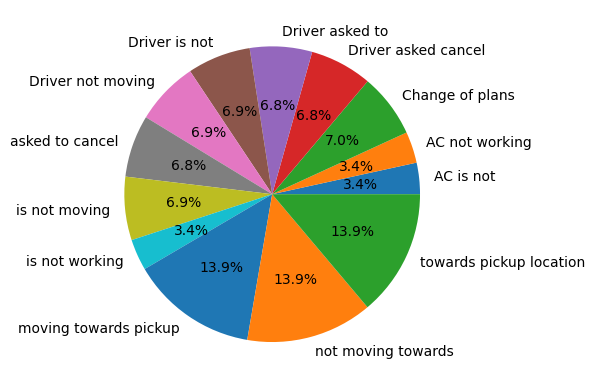

In [171]:
plt.pie(x=sorted_dict.values(),labels=sorted_dict.keys(),autopct="%1.1f%%")

### Cancelled Rides by Driver 
+ 27000 rides are cancle by driver 

In [177]:
total_null_value = df["Cancelled Rides by Driver"].isnull().sum()
dataset_len = df.shape[0] 

total_number_of_cancelation = dataset_len - total_null_value
print("Total ride cancelation by driver:",total_number_of_cancelation)

Total ride cancelation by driver: 27000


In [179]:
ride_cancelation_by_driver = df.loc[df["Cancelled Rides by Driver"].isnull() == False]
ride_cancelation_by_driver.shape 

(27000, 21)

In [184]:
ride_cancelation_by_driver["Driver Cancellation Reason"]

12              Personal & Car related issues
17                     Customer related issue
19                     Customer related issue
26              Personal & Car related issues
30        More than permitted people in there
                         ...                 
149959          Personal & Car related issues
149973                 Customer related issue
149977          Personal & Car related issues
149979         The customer was coughing/sick
149990          Personal & Car related issues
Name: Driver Cancellation Reason, Length: 27000, dtype: str

In [187]:
dr_tokens = sentence_convert_into_token(ride_cancelation_by_driver["Driver Cancellation Reason"])
dr_tokens
# dr_ngram = text_vectorize(tokens,3)
# dr_word_freq_dict = word_frequency(ngram)
# print(dr_word_freq_dict)

[['Driver', 'not', 'moving', 'towards', 'pickup', 'location'],
 ['Driver', 'is', 'not', 'moving', 'towards', 'pickup', 'location'],
 ['Driver', 'not', 'moving', 'towards', 'pickup', 'location'],
 ['Driver', 'is', 'not', 'moving', 'towards', 'pickup', 'location'],
 ['Driver', 'asked', 'cancel'],
 ['Driver', 'asked', 'to', 'cancel'],
 ['Driver', 'not', 'moving', 'towards', 'pickup', 'location'],
 ['Driver', 'is', 'not', 'moving', 'towards', 'pickup', 'location'],
 ['Driver', 'asked', 'cancel'],
 ['Driver', 'asked', 'to', 'cancel'],
 ['AC', 'not', 'working'],
 ['AC', 'is', 'not', 'working'],
 ['Driver', 'asked', 'cancel'],
 ['Driver', 'asked', 'to', 'cancel'],
 ['Driver', 'asked', 'cancel'],
 ['Driver', 'asked', 'to', 'cancel'],
 ['Change', 'plans'],
 ['Change', 'of', 'plans'],
 ['Wrong', 'Address'],
 ['Wrong', 'Address'],
 ['Driver', 'asked', 'cancel'],
 ['Driver', 'asked', 'to', 'cancel'],
 ['Change', 'plans'],
 ['Change', 'of', 'plans'],
 ['Change', 'plans'],
 ['Change', 'of', 'plans']

In [172]:
df.columns 

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')